<a href="https://colab.research.google.com/github/Sam-Gyu/anime-analysis/blob/main/anime_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import html
from collections import Counter

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': '#F8FAFC'})


# Load Data

In [17]:
df = pd.read_csv('/content/anime.csv')

print("Shape:", df.shape)
df.head()

Shape: (12294, 7)


,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [19]:
df.describe(include='all')

,anime_id,name,genre,type,episodes,rating,members
count,12294.000000,12294,12232,12269,12294,12064.000000,1.229400e+04
unique,NaN,12292,3264,6,187,NaN,NaN
top,NaN,Saru Kani Gassen,Hentai,TV,1,NaN,NaN
freq,NaN,2,823,3787,5677,NaN,NaN
mean,14058.221653,NaN,NaN,NaN,NaN,6.473902,1.807134e+04
std,11455.294701,NaN,NaN,NaN,NaN,1.026746,5.482068e+04
min,1.000000,NaN,NaN,NaN,NaN,1.670000,5.000000e+00
25%,3484.250000,NaN,NaN,NaN,NaN,5.880000,2.250000e+02
50%,10260.500000,NaN,NaN,NaN,NaN,6.570000,1.550000e+03
75%,24794.500000,NaN,NaN,NaN,NaN,7.180000,9.437000e+03


In [20]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Unique values per column:")
print(df.nunique())

Missing values per column:
anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

Unique values per column:
anime_id    12294
name        12292
genre        3264
type            6
episodes      187
rating        598
members      6706
dtype: int64


In [21]:
(df['episodes'] == 'Unknown').sum()

np.int64(340)

# Data Preprocessing



## Data Preprocessing & Cleaning

Steps applied:
- Convert `episodes` from string → numeric (replace `'Unknown'` → `NaN`)
- Drop rows with missing `rating` and `episodes`
- Fill missing `genre` and `type` with `'Unknown'`
- Decode HTML entities in `name` (e.g. `&#039;` → `'`)


In [22]:
df_clean = df.copy()

# Fix episodes: 'Unknown' → NaN, then cast to numeric
df_clean['episodes'] = pd.to_numeric(
    df_clean['episodes'].replace('Unknown', np.nan), errors='coerce'
)

# Drop rows with no rating, episodes
df_clean.dropna(subset=['episodes'], inplace=True)
df_clean.dropna(subset=['rating'], inplace=True)

# Fill missing genre and type
df_clean['genre'] = df_clean['genre'].fillna('Unknown')
df_clean['type']  = df_clean['type'].fillna('Unknown')

# Decode HTML entities in anime names
df_clean['name'] = df_clean['name'].apply(lambda x: html.unescape(str(x)))
df_clean['name'] = df_clean['name'].apply(lambda x: x.strip())

# Drop duplicated names after remove HTML entities
print(df_clean['name'].duplicated().sum())
df_clean.drop_duplicates(subset=['name'], inplace=True)
print(df_clean['name'].duplicated().sum())

print("Preprocessing done!")
print(f"   Original shape : {df.shape}")
print(f"   Cleaned shape  : {df_clean.shape}")
print(f"   Rows dropped   : {df.shape[0] - df_clean.shape[0]}")

2
0
Preprocessing done!
   Original shape : (12294, 7)
   Cleaned shape  : (11874, 7)
   Rows dropped   : 420


In [23]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [24]:
print("Cleaned dtypes:")
print(df_clean.dtypes)
print()
df_clean.describe()

Cleaned dtypes:
anime_id      int64
name         object
genre        object
type         object
episodes    float64
rating      float64
members       int64
dtype: object



,anime_id,episodes,rating,members
count,11874.000000,11874.000000,11874.000000,1.187400e+04
mean,13467.785919,12.449217,6.480430,1.844455e+04
std,11139.320692,47.014786,1.021943,5.527962e+04
min,1.000000,1.000000,1.670000,1.200000e+01
25%,3350.500000,1.000000,5.890000,2.290000e+02
50%,9865.500000,2.000000,6.570000,1.573000e+03
75%,23404.000000,12.000000,7.187500,9.766750e+03
max,34519.000000,1818.000000,10.000000,1.013917e+06


#Exploratory Data Analysis

## 📊 Chart 1 — Rating Distribution

6.480429509853461
6.57


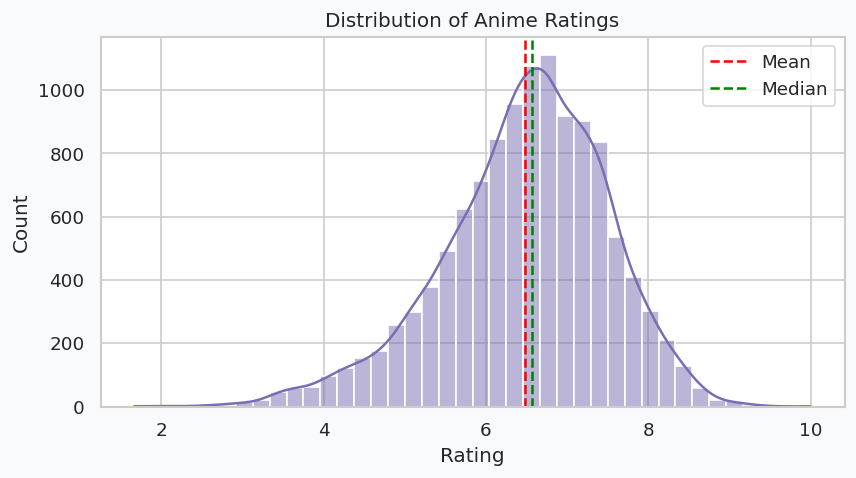

In [25]:
plt.figure(figsize=(8,4))

sns.histplot(df_clean['rating'], bins=40, kde=True, color=sns.color_palette("Purples_d", 1)[0])

print(df_clean['rating'].mean())
print(df_clean['rating'].median())

plt.axvline(df_clean['rating'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df_clean['rating'].median(), color='green', linestyle='--', label='Median')

plt.title("Distribution of Anime Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.legend()
plt.show()

**💡 Insight:** The rating distribution is slightly left-skewed with **mean ≈ 6.48** and **median ≈ 6.57**.
Most anime cluster between **5.5 – 7.5**. Very few titles score below 3 or above 9,
indicating that the community tends toward moderate scoring — extreme ratings are rare.


## 📊 Chart 2 — Number of Anime by Type

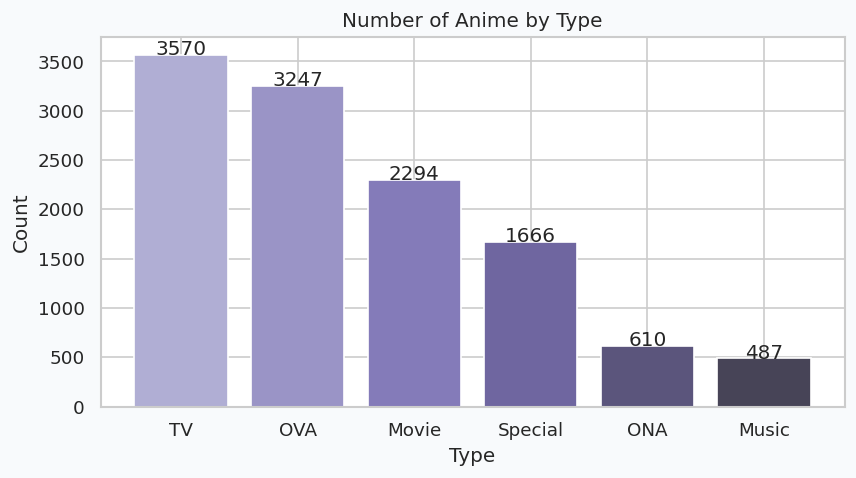

In [29]:
type_counts = df_clean['type'].value_counts()  # type_counts is a series like
                                               # TV       500
                                               # Movie    200
                                               # OVA      100
plt.figure(figsize=(8,4))

bars = plt.bar(type_counts.index, type_counts.values, color=sns.color_palette("Purples_d", len(type_counts)))

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha='center'
    )

plt.title("Number of Anime by Type")
plt.xlabel("Type")
plt.ylabel("Count")

plt.show()

**💡 Insight:** **TV series dominate** the dataset by a wide margin, followed by OVA and Movie.
Music and ONA formats are a small fraction. This reflects how the anime industry is primarily
driven by weekly broadcast TV productions.


## 📊 Chart 3 — Average Rating by Type

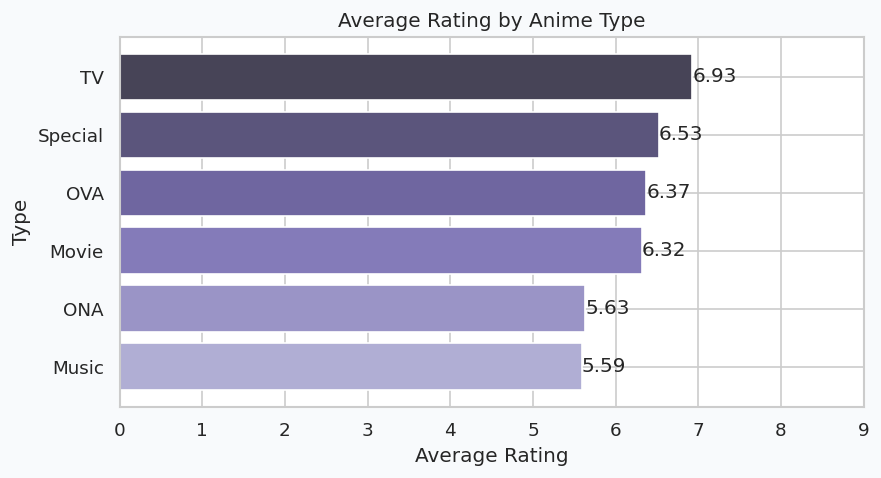

In [30]:
avg_rating_type = df_clean.groupby('type')['rating'].mean().sort_values()

plt.figure(figsize=(8,4))

bars = plt.barh(avg_rating_type.index, avg_rating_type.values, color=sns.color_palette("Purples_d", len(avg_rating_type)))

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va='center'
    )

plt.title("Average Rating by Anime Type")
plt.xlabel("Average Rating")
plt.ylabel("Type")

plt.xlim(0, 9)

plt.show()

**💡 Insight:** **Movies earn the highest average ratings**, followed by TV and Specials.
Music-type entries rank lowest. Movies may receive higher ratings because they are judged
as polished standalone works with larger budgets, compared to long-running episodic content.


## 📊 Chart 4 — Top 20 Genres by Frequency

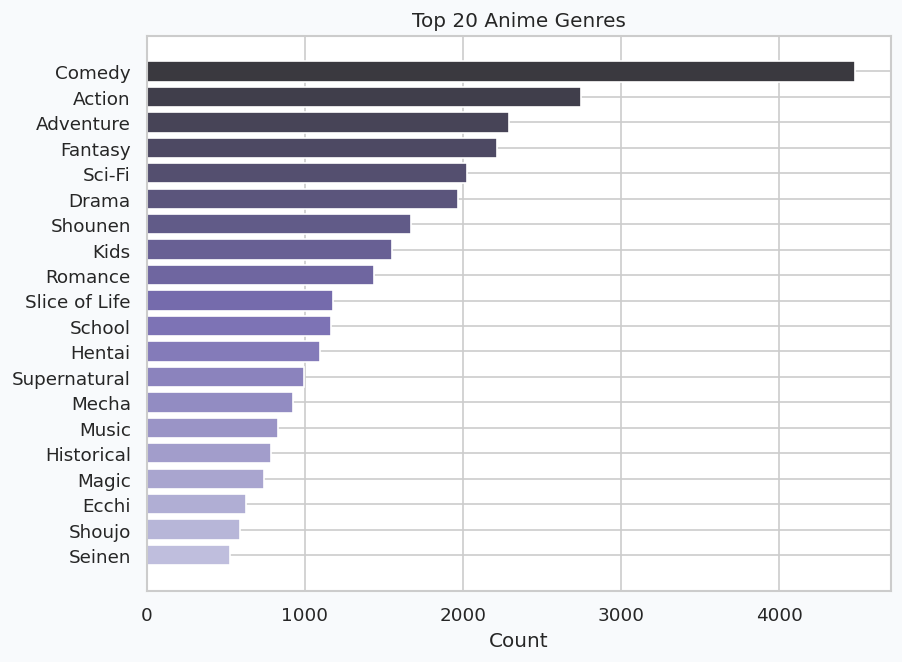

In [31]:
genre_list = []

for row in df_clean['genre']:
    genres = str(row).split(',')

    for g in genres:
        genre_list.append(g.strip())

genre_counts = pd.Series(genre_list).value_counts().head(20).sort_values()

plt.figure(figsize=(8,6))

plt.barh(genre_counts.index, genre_counts.values, color=sns.color_palette("Purples_d", len(genre_counts)))

plt.title("Top 20 Anime Genres")
plt.xlabel("Count")

plt.show()

**💡 Insight:** **Comedy, Action, and Adventure** are the three most frequent genres.
Drama and Sci-Fi also feature prominently. The landscape skews heavily toward
entertainment-driven genres, reflecting what the mainstream audience demands.


## 📊 Chart 5 — Community Members Distribution (log scale)

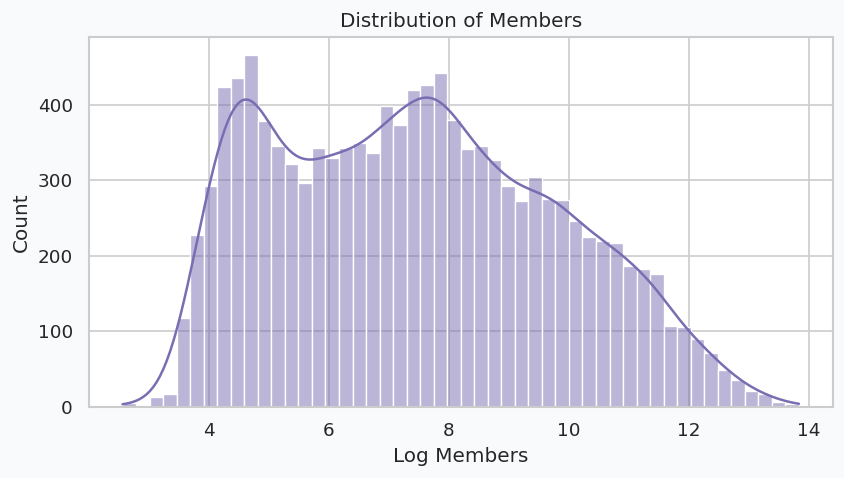

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8,4))

sns.histplot( np.log1p(df_clean['members']), bins=50, kde=True, color=sns.color_palette("Purples_d", 1)[0])

plt.title("Distribution of Members")
plt.xlabel("Log Members")
plt.ylabel("Count")

plt.show()

**💡 Insight:** The distribution of members (after log transformation) shows that most anime have a relatively low number of users, meaning they are followed by a small audience. Only a few anime have a very high number of members, which creates a long tail on the right side of the graph. This indicates that anime popularity is not evenly distributed: a small number of anime are extremely popular, while the majority remain less known. The log scale helps make this pattern clearer by reducing the impact of very large values.

## 📊 Chart 6 — Rating vs. Community Members

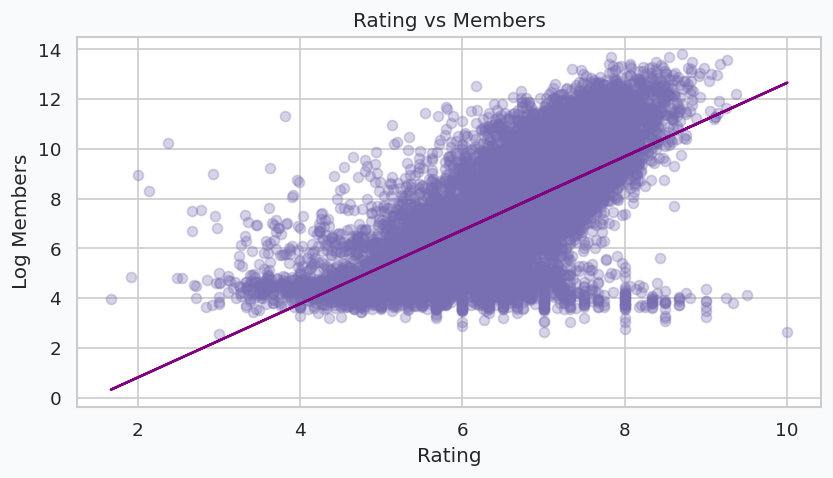

In [33]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,4))

x = df_clean['rating']
y = np.log1p(df_clean['members'])

plt.scatter(x, y, alpha=0.3, color=sns.color_palette("Purples_d", 1)[0])

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, color='Purple')

plt.title("Rating vs Members")
plt.xlabel("Rating")
plt.ylabel("Log Members")

plt.show()

**💡 Insight:** There is a **clear positive trend** — higher-rated anime tend to attract far more
community members. However, wide scatter at mid-ratings (5–8) suggests popularity is not
driven by quality alone; marketing, franchise loyalty, and seasonality also play major roles.


## 📊 Chart 7 — Episode Count Distribution (≤ 100 episodes)

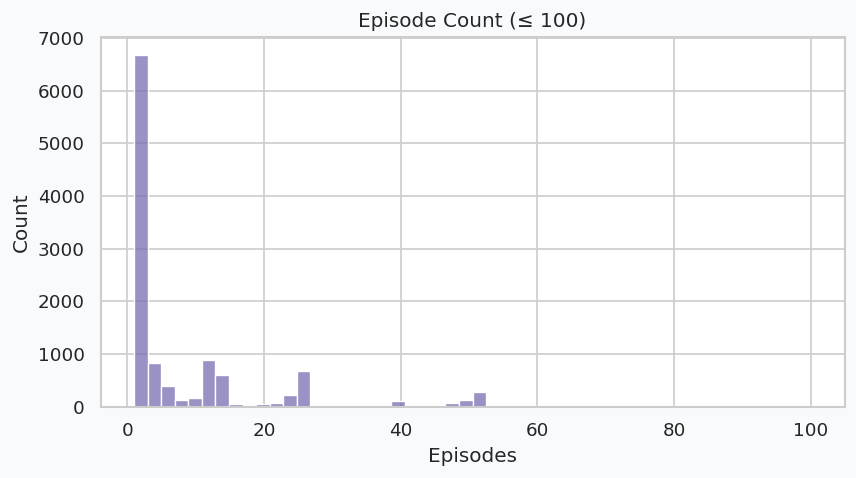

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

ep = df_clean[df_clean['episodes'] <= 100]['episodes']
plt.figure(figsize=(8,4))

sns.histplot(ep, bins=50, color=sns.color_palette("Purples_d", 1)[0])

plt.title("Episode Count (≤ 100)")
plt.xlabel("Episodes")
plt.ylabel("Count")

plt.show()

**💡 Insight:** Most anime have only one episode, which are usually **movies** or special **OVAs**. For series with multiple episodes, the most common lengths are around **12–13** episodes (**one season**) and **24–26** episodes (**two seasons**). This shows that anime episode counts usually follow standard TV broadcasting formats in Japan.


## 📊 Chart 8 — Correlation Heatmap

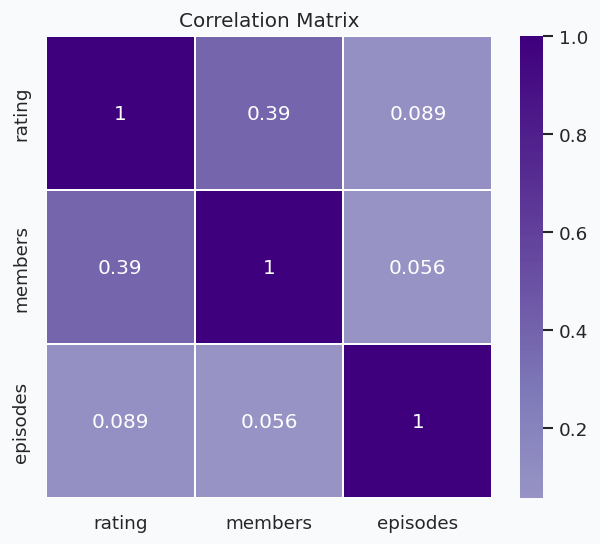

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_clean[['rating', 'members', 'episodes']].corr()

plt.figure(figsize=(6,5))

sns.heatmap(corr, annot=True, cmap='Purples', center=0, linewidth=0.1)

plt.title("Correlation Matrix")
plt.show()

**💡 Insight:** `rating` and `members` have a **moderate positive correlation (~0.37)**,
confirming that quality drives community size. `episodes` shows a weak positive correlation
with both — longer series accumulate audiences over time, but episode count alone does not
guarantee either quality or popularity.


## 📊 Chart 9 — Rating Distribution by Type (Boxplot)

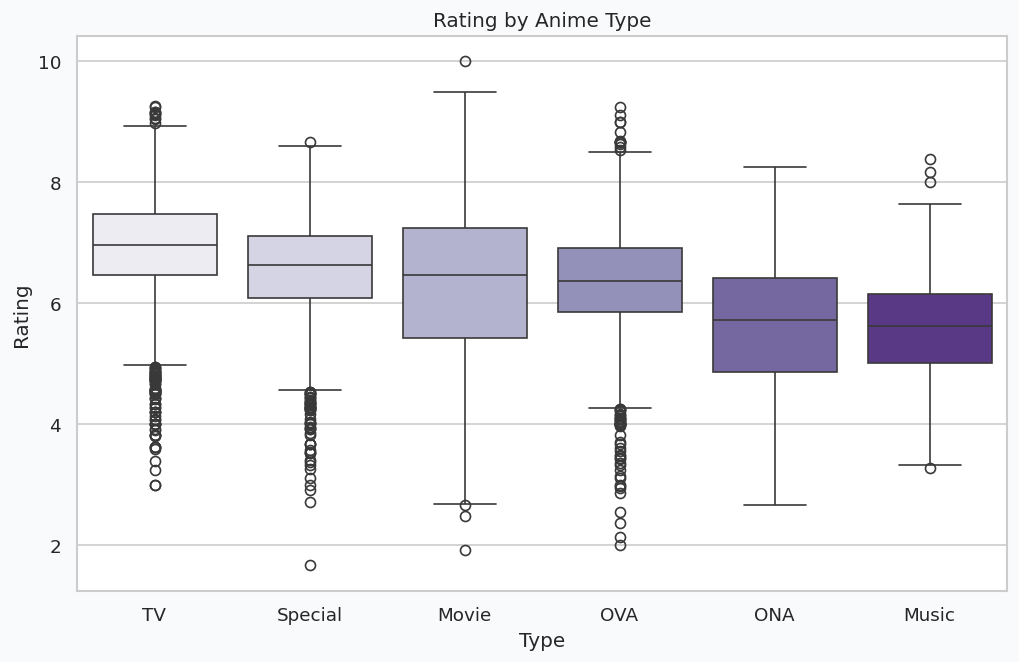

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

order = df_clean.groupby('type')['rating'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,6))

sns.boxplot( data=df_clean, x='type', y='rating', order=order, palette='Purples')

plt.title("Rating by Anime Type")
plt.xlabel("Type")
plt.ylabel("Rating")

plt.show()

**💡 Insight:** **Movies** show the highest median rating with a tighter IQR, confirming
greater consistency. TV and OVA have wider variance. Music content has the lowest median
and the widest spread. Numerous low-end outliers appear across all types.


## 📊 Chart 10 — Top 15 Most Popular Anime

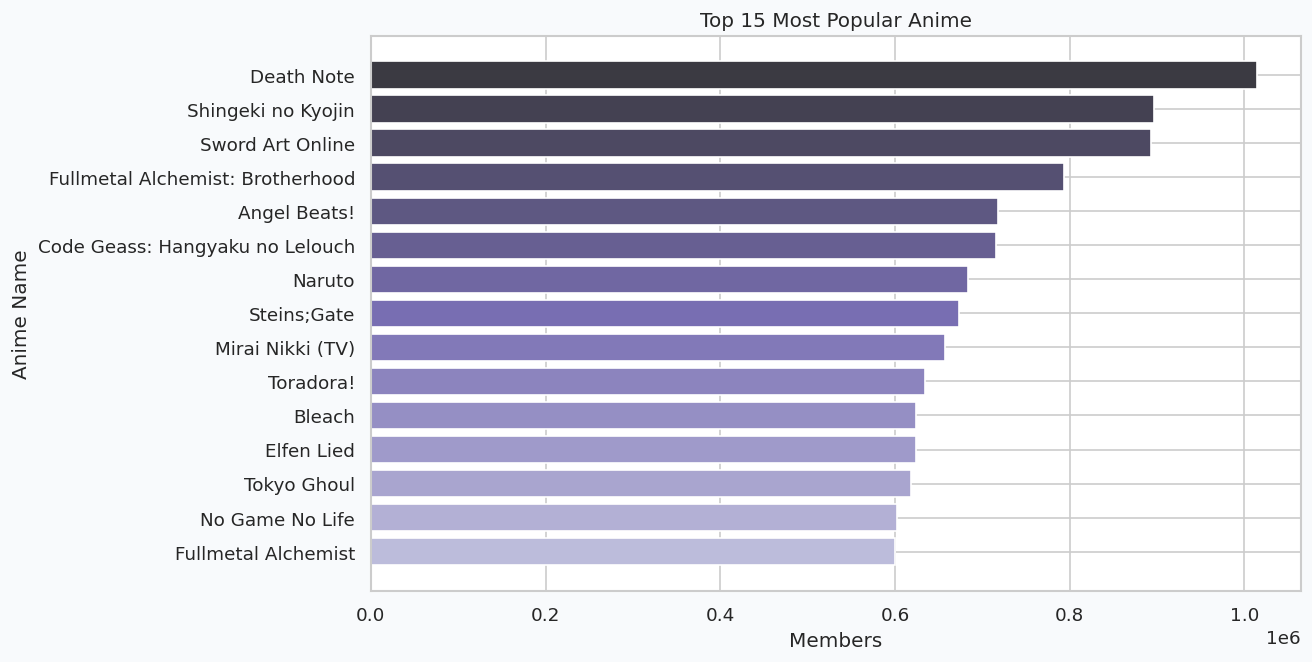

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

top15 = df_clean.nlargest(15, 'members')
top15 = top15.set_index('name')
top15 = top15.sort_values('members')

plt.figure(figsize=(10,6))
plt.barh(top15.index, top15['members'], color=sns.color_palette("Purples_d", len(top15)))

plt.title("Top 15 Most Popular Anime")
plt.xlabel("Members")
plt.ylabel("Anime Name")

plt.show()

**💡 Insight:** **Death Note, Sword Art Online, and Shingeki no Kyojin** lead in community size.
These titles span different genres (thriller, fantasy, action), showing that mainstream
success requires broad accessibility rather than genre specialization.


# YData Profiling Report

In [ ]:
!pip install ydata-profiling

In [56]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    df_clean,
    title="Anime Dataset – YData Profiling Report",
    explorative=True,
    minimal=False,
    correlations={
        "auto":    {"calculate": True},
        "pearson": {"calculate": True},
        "spearman":{"calculate": True},
    }
)

profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 7/7 [00:00<00:00,  9.33it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

> The interactive report above covers variable distributions, missing value matrices,
> Pearson/Spearman correlations, duplicate detection, and per-variable statistics.